In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed
np.random.seed(42)

# Create synthetic dataset
n_samples = 1000

temperature = np.random.uniform(70, 100, n_samples)
machine_speed = np.random.uniform(800, 1200, n_samples)
downtime = np.random.uniform(0, 120, n_samples)
humidity = np.random.uniform(30, 70, n_samples)
material_age = np.random.uniform(1, 24, n_samples)

defect_rate = (
    0.2 * (temperature - 70) / 30 +
    0.15 * downtime / 120 +
    0.1 * material_age / 24 +
    0.05 * (1200 - machine_speed) / 400 +
    0.1 * (humidity - 50) / 20 +
    np.random.normal(0, 0.1, n_samples)
)

defect_rate = np.clip(defect_rate, 0, 1)

data = pd.DataFrame({
    'Temperature (C)': temperature,
    'Machine_Speed (RPM)': machine_speed,
    'Downtime (min)': downtime,
    'Humidity (%)': humidity,
    'Material_Age (months)': material_age,
    'Defect_Rate': defect_rate
})

print("Dataset created successfully!")
print(data.head())

Dataset created successfully!
   Temperature (C)  Machine_Speed (RPM)  Downtime (min)  Humidity (%)  \
0        81.236204           874.053172       31.404682     56.908120   
1        98.521429          1016.760379       29.637456     61.867256   
2        91.959818          1149.178334      108.750550     40.018716   
3        87.959755          1092.889955       29.945544     54.994964   
4        74.680559          1122.624459       32.633967     52.869839   

   Material_Age (months)  Defect_Rate  
0              14.155905     0.188733  
1              19.524944     0.151754  
2              18.483701     0.274577  
3               4.539698     0.305790  
4               4.432738     0.168250  


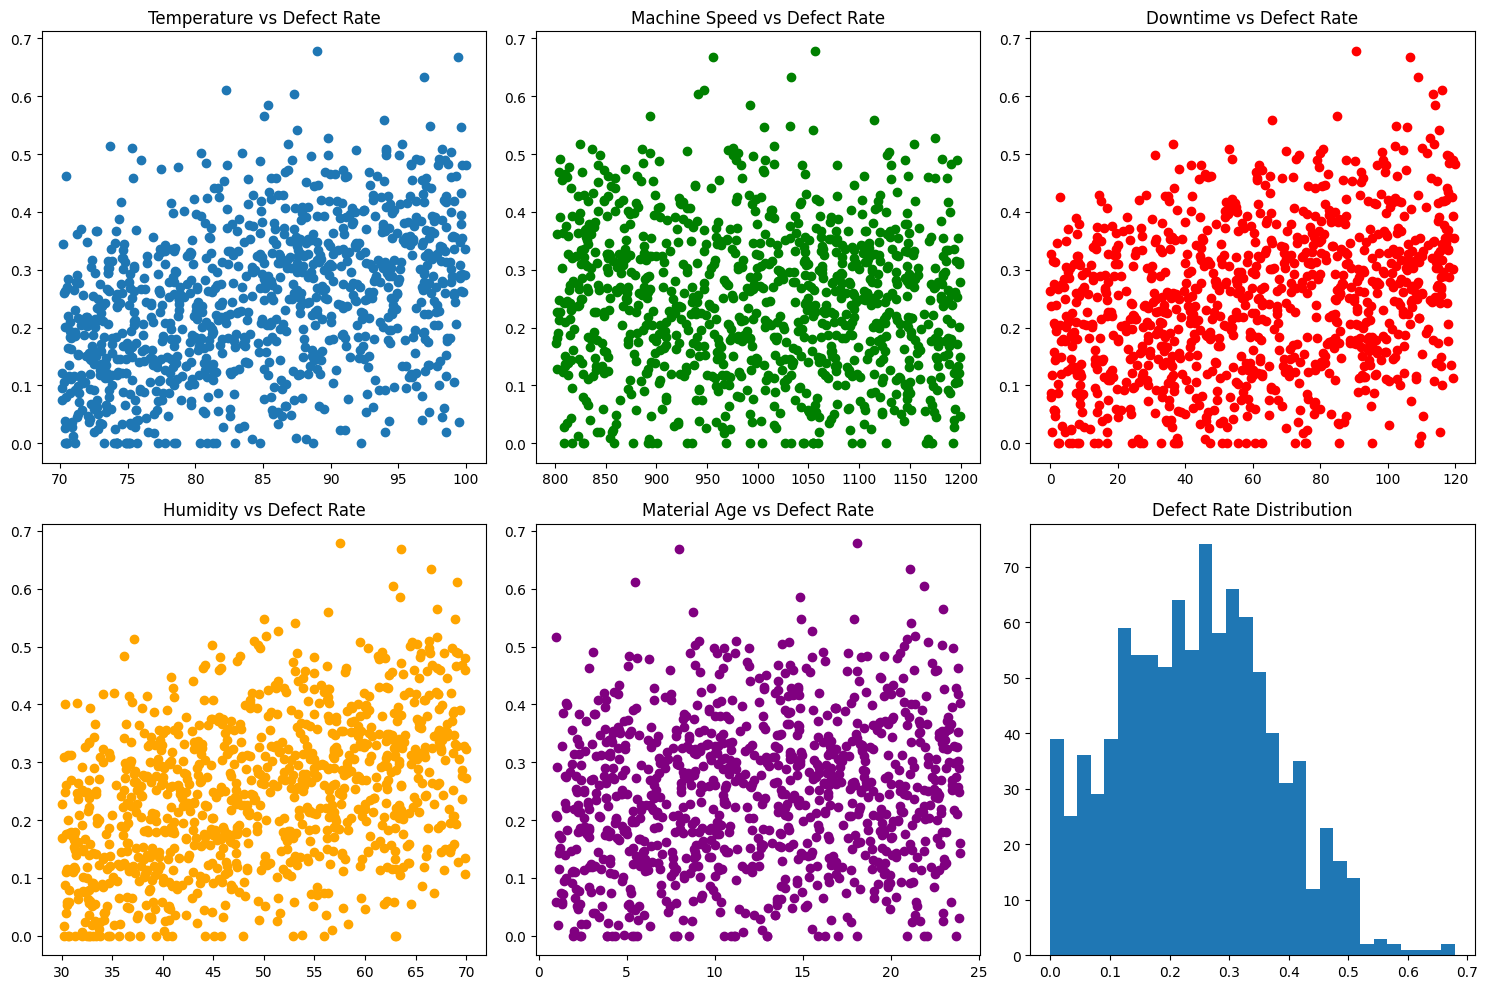

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].scatter(data['Temperature (C)'], data['Defect_Rate'])
axes[0, 0].set_title('Temperature vs Defect Rate')

axes[0, 1].scatter(data['Machine_Speed (RPM)'], data['Defect_Rate'], color='green')
axes[0, 1].set_title('Machine Speed vs Defect Rate')

axes[0, 2].scatter(data['Downtime (min)'], data['Defect_Rate'], color='red')
axes[0, 2].set_title('Downtime vs Defect Rate')

axes[1, 0].scatter(data['Humidity (%)'], data['Defect_Rate'], color='orange')
axes[1, 0].set_title('Humidity vs Defect Rate')

axes[1, 1].scatter(data['Material_Age (months)'], data['Defect_Rate'], color='purple')
axes[1, 1].set_title('Material Age vs Defect Rate')

axes[1, 2].hist(data['Defect_Rate'], bins=30)
axes[1, 2].set_title('Defect Rate Distribution')

plt.tight_layout()
plt.show()

In [6]:
X = data.drop('Defect_Rate', axis=1)
y = data['Defect_Rate']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [7]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R2 Score:", lr_r2)

Linear Regression Results
RMSE: 0.10039521306838006
MAE: 0.07829134550081202
R2 Score: 0.34091322436321037


In [8]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R2 Score:", rf_r2)

Random Forest Results
RMSE: 0.10565452771215716
MAE: 0.0821520285264864
R2 Score: 0.27005050532424335


In [9]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae],
    'R2': [lr_r2, rf_r2]
})

print(comparison)

               Model      RMSE       MAE        R2
0  Linear Regression  0.100395  0.078291  0.340913
1      Random Forest  0.105655  0.082152  0.270051


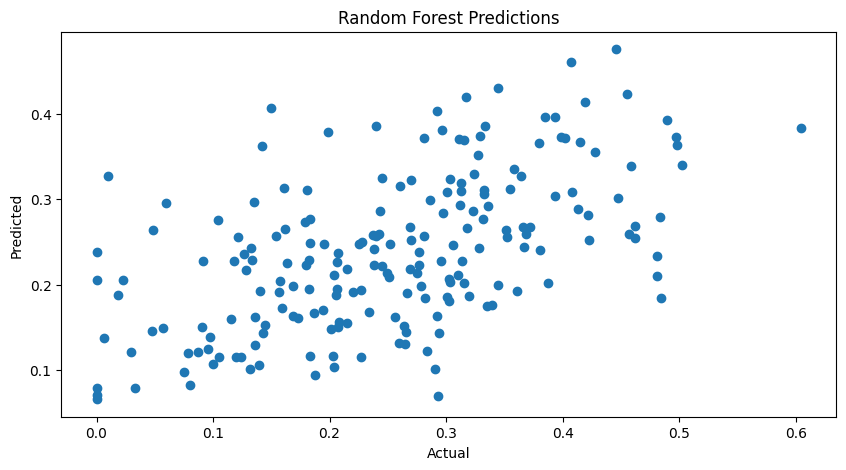

In [10]:
plt.figure(figsize=(10,5))

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Predictions")

plt.show()

In [11]:
results = f"""
Random Forest Results

RMSE: {rf_rmse}
MAE: {rf_mae}
R2 Score: {rf_r2}
"""

with open("results.txt", "w") as f:
    f.write(results)

print("Results saved!")

Results saved!
